## 1. Conceptual Overview

### What is Linear Regression?

Linear regression finds the **best-fit straight line** through data points to predict a continuous outcome.

**Simple Linear Regression**: One input variable (X) predicts one output (y)  
- Example: Study hours → Exam score

**Multiple Linear Regression**: Multiple input variables (X₁, X₂, ...) predict one output (y)  
- Example: Study hours + Sleep hours → Exam score

### When to Use
- Target variable is **continuous** (numbers like price, temperature, score)
- You expect a **linear relationship** between inputs and output

### Key Assumptions
1. **Linearity**: Relationship between X and y is linear
2. **Independence**: Observations are independent of each other
3. **Homoscedasticity**: Constant variance of errors
4. **Normality**: Errors are normally distributed (for inference)

---

# Linear Regression - Complete Tutorial

**Goal**: Predict a continuous numerical outcome using one or more input variables.

**Contents:**
- Part 1: Simple Linear Regression fundamentals
- Part 2: All types of linear regression (Multiple, Polynomial, Ridge, Lasso, Elastic Net)

---

# PART 1: Simple Linear Regression Fundamentals

---

## 2. Setup and Imports

In [33]:
# Import essential libraries
import numpy as np  # for numerical operations
import pandas as pd  # for data manipulation
import matplotlib.pyplot as plt  # for visualization

# Set display options for cleaner output
np.set_printoptions(precision=4)
pd.set_option('display.precision', 4)

## 3. Create Synthetic Dataset

**Scenario**: We want to predict exam scores based on hours studied.

- X = Hours of study (input/feature/predictor)
- y = Exam score (output/target/response)

In [34]:
# Create a small dataset (10 students)
# X = hours studied, y = exam score

X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # hours studied
y = np.array([35, 45, 50, 55, 65, 70, 72, 80, 88, 95])  # exam scores

# Create a DataFrame to view data nicely
df = pd.DataFrame({'Hours_Studied': X, 'Exam_Score': y})
df

,Hours_Studied,Exam_Score
0,1,35
1,2,45
2,3,50
3,4,55
4,5,65
5,6,70
6,7,72
7,8,80
8,9,88
9,10,95


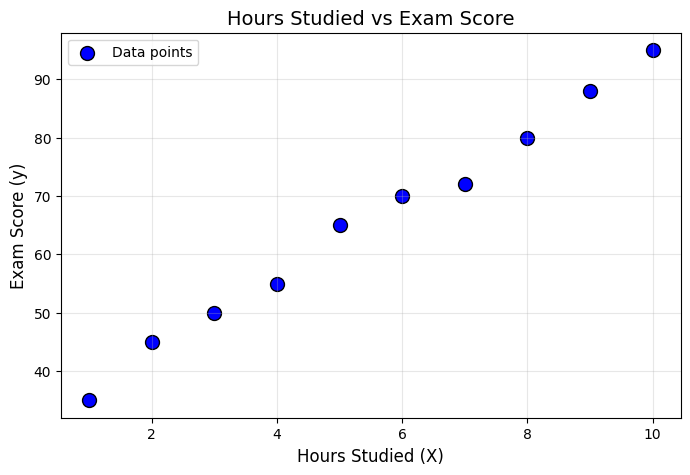

In [35]:
# Visualize the data with a scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', s=100, edgecolor='black', label='Data points')
plt.xlabel('Hours Studied (X)', fontsize=12)
plt.ylabel('Exam Score (y)', fontsize=12)
plt.title('Hours Studied vs Exam Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Observation: There's a clear positive linear trend - more hours = higher score

## 4. The Linear Regression Equation

### The Model

$$\hat{y} = \beta_0 + \beta_1 x$$

**Symbol meanings:**

| Symbol | Name | Meaning |
|--------|------|--------|
| $\hat{y}$ | y-hat | Predicted value of y |
| $x$ | feature | Input variable (hours studied) |
| $\beta_0$ | beta-zero (intercept) | Value of y when x = 0 (starting point) |
| $\beta_1$ | beta-one (slope) | Change in y for each unit increase in x |

### With Error Term (for actual data)

$$y = \beta_0 + \beta_1 x + \epsilon$$

Where $\epsilon$ (epsilon) = error/residual = difference between actual and predicted value

---

## 5. OLS Formulas (Ordinary Least Squares)

**Goal**: Find $\beta_0$ and $\beta_1$ that minimize the sum of squared errors.

### Formula for Slope ($\beta_1$)

$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

**In words**: 
- Numerator: Sum of (how far each x is from mean x) × (how far each y is from mean y)
- Denominator: Sum of squared deviations of x from its mean

### Formula for Intercept ($\beta_0$)

$$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

**In words**: Mean of y minus (slope × mean of x)

### Symbol Reference
- $\sum$ (Sigma) = summation (add up all values)
- $\bar{x}$ (x-bar) = mean of x values
- $\bar{y}$ (y-bar) = mean of y values
- $n$ = number of data points

---

## 6. Manual Calculation (From Scratch)

In [36]:
# Step 1: Calculate means
x_mean = np.mean(X)  # mean of hours studied
y_mean = np.mean(y)  # mean of exam scores

print(f"Mean of X (x̄): {x_mean}")
print(f"Mean of y (ȳ): {y_mean}")

Mean of X (x̄): 5.5
Mean of y (ȳ): 65.5


In [37]:
# Step 2: Calculate deviations from mean
x_deviation = X - x_mean  # (xᵢ - x̄) for each point
y_deviation = y - y_mean  # (yᵢ - ȳ) for each point

# Show calculations in a table
calc_df = pd.DataFrame({
    'X': X,
    'y': y,
    'x - x̄': x_deviation,
    'y - ȳ': y_deviation,
    '(x-x̄)(y-ȳ)': x_deviation * y_deviation,
    '(x-x̄)²': x_deviation ** 2
})
calc_df

,X,y,x - x̄,y - ȳ,(x-x̄)(y-ȳ),(x-x̄)²
0,1,35,-4.5,-30.5,137.25,20.25
1,2,45,-3.5,-20.5,71.75,12.25
2,3,50,-2.5,-15.5,38.75,6.25
3,4,55,-1.5,-10.5,15.75,2.25
4,5,65,-0.5,-0.5,0.25,0.25
5,6,70,0.5,4.5,2.25,0.25
6,7,72,1.5,6.5,9.75,2.25
7,8,80,2.5,14.5,36.25,6.25
8,9,88,3.5,22.5,78.75,12.25
9,10,95,4.5,29.5,132.75,20.25


In [38]:
# Step 3: Calculate β₁ (slope)
# Formula: β₁ = Σ(xᵢ - x̄)(yᵢ - ȳ) / Σ(xᵢ - x̄)²

numerator = np.sum(x_deviation * y_deviation)  # Σ(x-x̄)(y-ȳ)
denominator = np.sum(x_deviation ** 2)  # Σ(x-x̄)²

beta_1_manual = numerator / denominator

print(f"Numerator Σ(x-x̄)(y-ȳ): {numerator}")
print(f"Denominator Σ(x-x̄)²: {denominator}")
print(f"β₁ (slope): {beta_1_manual:.4f}")

Numerator Σ(x-x̄)(y-ȳ): 523.5
Denominator Σ(x-x̄)²: 82.5
β₁ (slope): 6.3455


In [39]:
# Step 4: Calculate β₀ (intercept)
# Formula: β₀ = ȳ - β₁ × x̄

beta_0_manual = y_mean - beta_1_manual * x_mean

print(f"β₀ (intercept): {beta_0_manual:.4f}")

β₀ (intercept): 30.6000


In [40]:
# Summary of manually calculated coefficients
print("=" * 40)
print("MANUAL CALCULATION RESULTS")
print("=" * 40)
print(f"Intercept (β₀): {beta_0_manual:.4f}")
print(f"Slope (β₁): {beta_1_manual:.4f}")
print("=" * 40)
print(f"\nEquation: ŷ = {beta_0_manual:.4f} + {beta_1_manual:.4f} × x")
print(f"\nInterpretation:")
print(f"  - Base score (0 hours): {beta_0_manual:.2f} points")
print(f"  - Each additional hour: +{beta_1_manual:.2f} points")

MANUAL CALCULATION RESULTS
Intercept (β₀): 30.6000
Slope (β₁): 6.3455

Equation: ŷ = 30.6000 + 6.3455 × x

Interpretation:
  - Base score (0 hours): 30.60 points
  - Each additional hour: +6.35 points


## 7. Using Scikit-Learn Library

In [41]:
# Import LinearRegression from sklearn
from sklearn.linear_model import LinearRegression

# sklearn requires X to be 2D (reshape from (n,) to (n,1))
X_reshaped = X.reshape(-1, 1)  # -1 means "figure out rows", 1 column

# Create and fit the model
model = LinearRegression()  # create model object
model.fit(X_reshaped, y)  # fit model to data (learn β₀ and β₁)

# Extract coefficients
beta_0_sklearn = model.intercept_  # intercept
beta_1_sklearn = model.coef_[0]  # slope (stored as array, so take first element)

print("SKLEARN RESULTS")
print(f"Intercept (β₀): {beta_0_sklearn:.4f}")
print(f"Slope (β₁): {beta_1_sklearn:.4f}")

SKLEARN RESULTS
Intercept (β₀): 30.6000
Slope (β₁): 6.3455


In [42]:
# Compare manual vs sklearn results
comparison_df = pd.DataFrame({
    'Coefficient': ['β₀ (Intercept)', 'β₁ (Slope)'],
    'Manual': [beta_0_manual, beta_1_manual],
    'Sklearn': [beta_0_sklearn, beta_1_sklearn],
    'Match': [np.isclose(beta_0_manual, beta_0_sklearn), 
              np.isclose(beta_1_manual, beta_1_sklearn)]
})
comparison_df

# They should match perfectly!

,Coefficient,Manual,Sklearn,Match
0,β₀ (Intercept),30.6000,30.6000,True
1,β₁ (Slope),6.3455,6.3455,True


## 8. Visualize the Regression Line

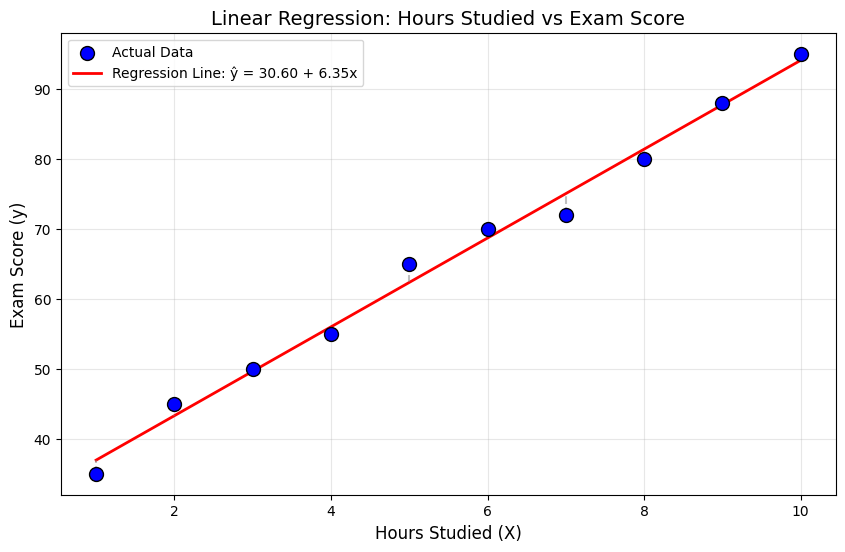

In [43]:
# Calculate predicted values using our equation
y_pred = beta_0_manual + beta_1_manual * X

# Create visualization
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(X, y, color='blue', s=100, edgecolor='black', 
            label='Actual Data', zorder=5)

# Plot regression line
plt.plot(X, y_pred, color='red', linewidth=2, 
         label=f'Regression Line: ŷ = {beta_0_manual:.2f} + {beta_1_manual:.2f}x')

# Plot residuals (vertical lines from points to line)
for i in range(len(X)):
    plt.vlines(X[i], y[i], y_pred[i], colors='gray', linestyles='dashed', alpha=0.5)

plt.xlabel('Hours Studied (X)', fontsize=12)
plt.ylabel('Exam Score (y)', fontsize=12)
plt.title('Linear Regression: Hours Studied vs Exam Score', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Gray dashed lines show "residuals" - the errors between actual and predicted

## 9. Model Evaluation Metrics

### Key Metrics

**1. Residuals (Errors)**
$$e_i = y_i - \hat{y}_i$$
Difference between actual and predicted value.

**2. Mean Squared Error (MSE)**
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$
Average of squared errors. Lower is better.

**3. Root Mean Squared Error (RMSE)**
$$RMSE = \sqrt{MSE}$$
Same units as y. Easier to interpret.

**4. R-squared (Coefficient of Determination)**
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$
Proportion of variance explained by model. Range: 0 to 1. Higher is better.

---

In [44]:
# Calculate residuals (errors)
residuals = y - y_pred

# Show actual, predicted, and residual for each point
results_df = pd.DataFrame({
    'X (Hours)': X,
    'Actual y': y,
    'Predicted ŷ': np.round(y_pred, 2),
    'Residual (y - ŷ)': np.round(residuals, 2)
})
results_df

,X (Hours),Actual y,Predicted ŷ,Residual (y - ŷ)
0,1,35,36.95,-1.95
1,2,45,43.29,1.71
2,3,50,49.64,0.36
3,4,55,55.98,-0.98
4,5,65,62.33,2.67
5,6,70,68.67,1.33
6,7,72,75.02,-3.02
7,8,80,81.36,-1.36
8,9,88,87.71,0.29
9,10,95,94.05,0.95


In [45]:
# Calculate evaluation metrics manually
n = len(y)

# MSE: Mean Squared Error
MSE = np.sum(residuals ** 2) / n

# RMSE: Root Mean Squared Error  
RMSE = np.sqrt(MSE)

# R²: Coefficient of Determination
SS_res = np.sum(residuals ** 2)  # sum of squared residuals
SS_tot = np.sum((y - y_mean) ** 2)  # total sum of squares
R_squared = 1 - (SS_res / SS_tot)

print("MODEL EVALUATION METRICS")
print("=" * 40)
print(f"MSE:  {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")
print(f"R²:   {R_squared:.4f}")
print("=" * 40)

MODEL EVALUATION METRICS
MSE:  2.8655
RMSE: 1.6928
R²:   0.9914


In [46]:
# Verify with sklearn
from sklearn.metrics import mean_squared_error, r2_score

print("Verification with sklearn:")
print(f"MSE:  {mean_squared_error(y, y_pred):.4f}")
print(f"R²:   {r2_score(y, y_pred):.4f}")
print(f"R² from model.score(): {model.score(X_reshaped, y):.4f}")

Verification with sklearn:
MSE:  2.8655
R²:   0.9914
R² from model.score(): 0.9914


## 10A. Full OLS Summary Using Statsmodels

Statsmodels provides a comprehensive regression output with statistical tests.

### What the OLS Summary Contains:
| Component | Meaning |
|-----------|---------|
| **coef** | Estimated coefficients (β₀, β₁, ...) |
| **std err** | Standard error of each coefficient |
| **t** | t-statistic = coef / std err |
| **P>\|t\|** | p-value for hypothesis test (H₀: coef = 0) |
| **[0.025, 0.975]** | 95% confidence interval |
| **R-squared** | Proportion of variance explained |
| **Adj. R-squared** | R² adjusted for number of predictors |
| **F-statistic** | Tests if model is better than no predictors |

In [47]:
# Generate full OLS summary using statsmodels
import statsmodels.api as sm

# Add constant (intercept) to X - statsmodels requires this explicitly
X_with_const = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X_with_const).fit()

# Print full summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     927.4
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.47e-09
Time:                        18:02:42   Log-Likelihood:                -19.453
No. Observations:                  10   AIC:                             42.91
Df Residuals:                       8   BIC:                             43.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.6000      1.293     23.668      0.0

## 10B. Interpretation of OLS Results

### Coefficient Interpretation

$$\hat{y} = \beta_0 + \beta_1 x$$

- **β₀ (const/intercept)**: Expected y when x = 0
- **β₁ (slope)**: Change in y for each 1-unit increase in x

### Statistical Significance

**Hypothesis Test for each coefficient:**
- H₀: β = 0 (no effect)
- H₁: β ≠ 0 (has effect)
- **Decision**: Reject H₀ if p-value < 0.05

### R² Interpretation
- R² = 0.97 means 97% of variance in y is explained by x
- Higher R² = better fit (but beware of overfitting)

### F-statistic Interpretation
- Tests: "Is at least one predictor useful?"
- H₀: All coefficients = 0 (model is useless)
- H₁: At least one coefficient ≠ 0
- Low p-value → model is statistically significant

In [48]:
# Extract and interpret key statistics
print("OLS INTERPRETATION")
print("=" * 60)

# Coefficients
print(f"\n1. COEFFICIENTS:")
print(f"   β₀ (intercept) = {ols_model.params[0]:.4f}")
print(f"   β₁ (slope)     = {ols_model.params[1]:.4f}")
print(f"   → Each extra hour of study adds ~{ols_model.params[1]:.2f} points to exam score")

# P-values
print(f"\n2. P-VALUES:")
print(f"   p-value for β₀ = {ols_model.pvalues[0]:.4f} {'(significant)' if ols_model.pvalues[0] < 0.05 else '(not significant)'}")
print(f"   p-value for β₁ = {ols_model.pvalues[1]:.6f} {'(significant)' if ols_model.pvalues[1] < 0.05 else '(not significant)'}")
print(f"   → Since p < 0.05, hours studied has a statistically significant effect")

# R-squared
print(f"\n3. R-SQUARED:")
print(f"   R² = {ols_model.rsquared:.4f}")
print(f"   Adj. R² = {ols_model.rsquared_adj:.4f}")
print(f"   → Model explains {ols_model.rsquared*100:.1f}% of variance in exam scores")

# F-statistic
print(f"\n4. F-STATISTIC:")
print(f"   F = {ols_model.fvalue:.4f}, p-value = {ols_model.f_pvalue:.6f}")
print(f"   → Model is {'statistically significant' if ols_model.f_pvalue < 0.05 else 'not significant'}")

# Confidence intervals
print(f"\n5. 95% CONFIDENCE INTERVALS:")
print(f"   β₀: [{ols_model.conf_int().iloc[0,0]:.4f}, {ols_model.conf_int().iloc[0,1]:.4f}]")
print(f"   β₁: [{ols_model.conf_int().iloc[1,0]:.4f}, {ols_model.conf_int().iloc[1,1]:.4f}]")
print("=" * 60)

OLS INTERPRETATION

1. COEFFICIENTS:
   β₀ (intercept) = 30.6000
   β₁ (slope)     = 6.3455
   → Each extra hour of study adds ~6.35 points to exam score

2. P-VALUES:
   p-value for β₀ = 0.0000 (significant)
   p-value for β₁ = 0.000000 (significant)
   → Since p < 0.05, hours studied has a statistically significant effect

3. R-SQUARED:
   R² = 0.9914
   Adj. R² = 0.9904
   → Model explains 99.1% of variance in exam scores

4. F-STATISTIC:
   F = 927.4188, p-value = 0.000000
   → Model is statistically significant

5. 95% CONFIDENCE INTERVALS:


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

## 10. Interpretation of Results

### What do these numbers mean?

| Metric | Value | Interpretation |
|--------|-------|---------------|
| **β₀ (Intercept)** | ~28 | Predicted score with 0 hours study |
| **β₁ (Slope)** | ~6.6 | Each extra hour → ~6.6 more points |
| **RMSE** | ~3.5 | Typical prediction error is ~3.5 points |
| **R²** | ~0.97 | Model explains 97% of score variation |

### Making Predictions

In [ ]:
# Predict score for a new student who studies 5.5 hours
new_hours = 5.5
predicted_score = beta_0_manual + beta_1_manual * new_hours

print(f"If a student studies {new_hours} hours:")
print(f"Predicted exam score = {beta_0_manual:.2f} + {beta_1_manual:.2f} × {new_hours}")
print(f"Predicted exam score = {predicted_score:.2f}")

If a student studies 5.5 hours:
Predicted exam score = 30.60 + 6.35 × 5.5
Predicted exam score = 65.50


## 11. Visualize Residuals (Model Diagnostics)

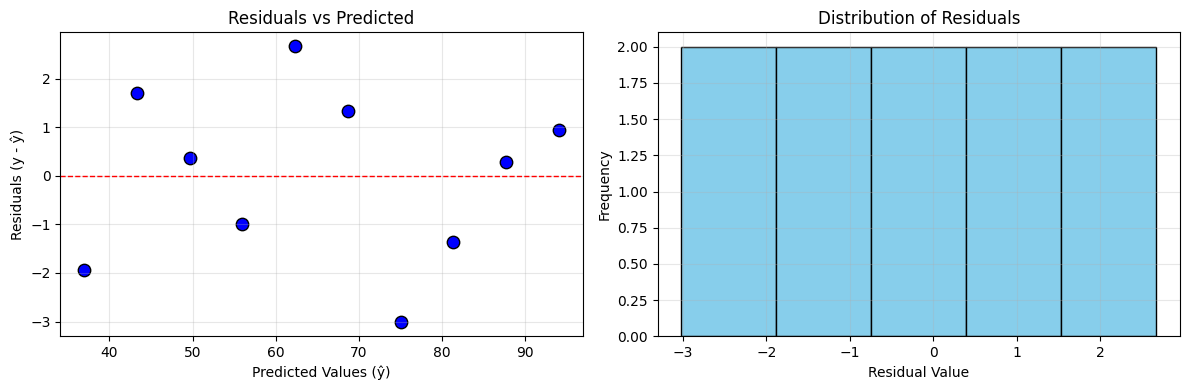

In [ ]:
# Create diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Residuals vs Predicted values
axes[0].scatter(y_pred, residuals, color='blue', s=80, edgecolor='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Values (ŷ)')
axes[0].set_ylabel('Residuals (y - ŷ)')
axes[0].set_title('Residuals vs Predicted')
axes[0].grid(True, alpha=0.3)

# Plot 2: Histogram of residuals
axes[1].hist(residuals, bins=5, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Good model: residuals randomly scattered around 0, roughly normal distribution

## 12. Summary

### Key Takeaways

1. **Linear regression** finds the best-fit line: $\hat{y} = \beta_0 + \beta_1 x$

2. **OLS method** minimizes sum of squared errors to find $\beta_0$ and $\beta_1$

3. **Slope ($\beta_1$)** tells us how much y changes per unit change in x

4. **Intercept ($\beta_0$)** is the predicted y when x = 0

5. **R²** tells us what proportion of variance in y is explained by x (0 to 1)

6. **RMSE** tells us the typical prediction error in the same units as y

### Formulas Cheat Sheet

| Formula | Purpose |
|---------|--------|
| $\beta_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$ | Calculate slope |
| $\beta_0 = \bar{y} - \beta_1 \bar{x}$ | Calculate intercept |
| $MSE = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Average squared error |
| $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Explained variance |

---
**End of Linear Regression Tutorial**

---

# PART 2: Types of Linear Regression

---

## 13. Simple Linear Regression (Review)

### Formula
$$\hat{y} = \beta_0 + \beta_1 x$$

### OLS Estimator (Closed-Form Solution)
$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} = \frac{Cov(x,y)}{Var(x)}$$

$$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

### What Makes It Different
- Only **one predictor** variable
- Assumes **linear relationship** between x and y
- Minimizes sum of squared residuals (SSE)

### When to Use
- Single input variable predicting continuous output
- You expect a straight-line relationship
- Baseline model before trying more complex approaches

In [ ]:
# Simple Linear Regression - already demonstrated above
# Quick recap with the same data
print("SIMPLE LINEAR REGRESSION RECAP")
print(f"Model: ŷ = {beta_0_manual:.4f} + {beta_1_manual:.4f} × x")
print(f"R² = {R_squared:.4f}")

---

## 14. Multiple Linear Regression

### Formula
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p$$

### Matrix Form (OLS Estimator)
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

This is the **closed-form solution** for multiple regression.

### What Makes It Different
- **Multiple predictors** (x₁, x₂, ..., xₚ)
- Each βᵢ shows effect of xᵢ **holding other variables constant**
- Can model more complex relationships

### When to Use
- Multiple factors influence the outcome
- Want to understand individual effect of each predictor
- Need to control for confounding variables

In [ ]:
# Multiple Linear Regression - Synthetic Dataset
# Scenario: Predict exam score from hours_studied, sleep_hours, practice_problems

np.random.seed(42)
n_samples = 15

# Create features
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 2, 4, 6, 8, 10])
sleep_hours = np.array([4, 5, 6, 7, 8, 6, 7, 8, 7, 8, 8, 7, 6, 5, 9])
practice_problems = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 8, 18, 28, 38, 48])

# Target: exam_score = 30 + 5*hours + 2*sleep + 0.3*practice + noise
exam_score = 30 + 5*hours_studied + 2*sleep_hours + 0.3*practice_problems + np.random.normal(0, 3, n_samples)

# Create DataFrame
df_multi = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Sleep_Hours': sleep_hours,
    'Practice_Problems': practice_problems,
    'Exam_Score': np.round(exam_score, 1)
})
df_multi.head(10)

In [ ]:
# Fit Multiple Linear Regression
X_multi = df_multi[['Hours_Studied', 'Sleep_Hours', 'Practice_Problems']]
y_multi = df_multi['Exam_Score']

# Using statsmodels for full summary
X_multi_const = sm.add_constant(X_multi)
multi_model = sm.OLS(y_multi, X_multi_const).fit()
print(multi_model.summary())

In [ ]:
# Interpretation of Multiple Regression
print("MULTIPLE REGRESSION INTERPRETATION")
print("=" * 50)
print(f"\nModel: ŷ = {multi_model.params[0]:.2f} + {multi_model.params[1]:.2f}×Hours + {multi_model.params[2]:.2f}×Sleep + {multi_model.params[3]:.2f}×Practice")
print(f"\n• Each extra hour of study → +{multi_model.params[1]:.2f} points (holding others constant)")
print(f"• Each extra hour of sleep → +{multi_model.params[2]:.2f} points (holding others constant)")
print(f"• Each extra practice problem → +{multi_model.params[3]:.2f} points (holding others constant)")
print(f"\nR² = {multi_model.rsquared:.4f} (explains {multi_model.rsquared*100:.1f}% of variance)")

---

## 15. Polynomial Regression

### Formula
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + ... + \beta_d x^d$$

Where $d$ = degree of the polynomial.

### What Makes It Different
- Captures **non-linear relationships** using polynomial features
- Still uses linear regression (linear in coefficients, not in x)
- Higher degree → more flexible but risk of **overfitting**

### When to Use
- Relationship between x and y is **curved**, not straight
- Simple linear regression gives poor fit
- Be careful: high degree can cause overfitting

In [ ]:
# Polynomial Regression - Synthetic Dataset with curved relationship
from sklearn.preprocessing import PolynomialFeatures

# Data with quadratic relationship: y = 10 + 2x - 0.5x² + noise
X_poly = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y_poly = 10 + 2*X_poly.flatten() + 0.5*X_poly.flatten()**2 + np.random.normal(0, 2, 10)

# Compare: Linear vs Polynomial (degree 2)
# Linear fit
lin_model = LinearRegression().fit(X_poly, y_poly)
y_pred_lin = lin_model.predict(X_poly)

# Polynomial fit (degree 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_transformed = poly_features.fit_transform(X_poly)  # creates [x, x²]
poly_model = LinearRegression().fit(X_poly_transformed, y_poly)
y_pred_poly = poly_model.predict(X_poly_transformed)

# Visualize
plt.figure(figsize=(10, 5))
plt.scatter(X_poly, y_poly, color='blue', s=100, label='Data', zorder=5)
plt.plot(X_poly, y_pred_lin, 'r--', linewidth=2, label=f'Linear (R²={r2_score(y_poly, y_pred_lin):.3f})')
plt.plot(X_poly, y_pred_poly, 'g-', linewidth=2, label=f'Polynomial deg=2 (R²={r2_score(y_poly, y_pred_poly):.3f})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Polynomial model coefficients
print("POLYNOMIAL REGRESSION (degree=2)")
print("=" * 50)
print(f"Model: ŷ = {poly_model.intercept_:.4f} + {poly_model.coef_[0]:.4f}×x + {poly_model.coef_[1]:.4f}×x²")
print(f"R² = {r2_score(y_poly, y_pred_poly):.4f}")
print("\n→ Polynomial captures the curve better than linear!")

---

## 16. Ridge Regression (L2 Regularization)

### Loss Function
$$\mathcal{L}_{Ridge} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}\beta_j^2$$

$$= SSE + \lambda \|\boldsymbol{\beta}\|_2^2$$

Where:
- First term: ordinary least squares (SSE)
- Second term: **L2 penalty** (sum of squared coefficients)
- $\lambda$ (lambda): regularization strength (higher = more shrinkage)

### What Makes It Different
- Adds penalty for large coefficients → **shrinks** them toward zero
- Helps with **multicollinearity** (correlated predictors)
- Never sets coefficients exactly to zero

### When to Use
- Many predictors, some may be correlated
- Want to prevent overfitting
- All features might be relevant (don't want feature selection)

In [ ]:
# Ridge Regression - Compare with OLS
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Use the multiple regression data
X_ridge = df_multi[['Hours_Studied', 'Sleep_Hours', 'Practice_Problems']].values
y_ridge = df_multi['Exam_Score'].values

# Standardize features (important for regularization)
scaler = StandardScaler()
X_ridge_scaled = scaler.fit_transform(X_ridge)

# Fit OLS (no regularization)
ols_ridge = LinearRegression().fit(X_ridge_scaled, y_ridge)

# Fit Ridge with different lambda values
ridge_1 = Ridge(alpha=1).fit(X_ridge_scaled, y_ridge)
ridge_10 = Ridge(alpha=10).fit(X_ridge_scaled, y_ridge)
ridge_100 = Ridge(alpha=100).fit(X_ridge_scaled, y_ridge)

# Compare coefficients
coef_comparison = pd.DataFrame({
    'Feature': ['Hours', 'Sleep', 'Practice'],
    'OLS (λ=0)': np.round(ols_ridge.coef_, 4),
    'Ridge (λ=1)': np.round(ridge_1.coef_, 4),
    'Ridge (λ=10)': np.round(ridge_10.coef_, 4),
    'Ridge (λ=100)': np.round(ridge_100.coef_, 4)
})
coef_comparison

# Notice: Higher λ → coefficients shrink toward zero

In [ ]:
# Visualize coefficient shrinkage
lambdas = [0.01, 0.1, 1, 10, 100, 1000]
coefs = []

for lam in lambdas:
    ridge = Ridge(alpha=lam).fit(X_ridge_scaled, y_ridge)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 5))
for i, feature in enumerate(['Hours', 'Sleep', 'Practice']):
    plt.plot(lambdas, coefs[:, i], 'o-', label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('λ (Regularization Strength)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Ridge: Coefficient Shrinkage as λ Increases', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.show()

print("→ As λ increases, all coefficients shrink toward zero (but never reach zero)")

---

## 17. Lasso Regression (L1 Regularization)

### Loss Function
$$\mathcal{L}_{Lasso} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}|\beta_j|$$

$$= SSE + \lambda \|\boldsymbol{\beta}\|_1$$

Where:
- First term: ordinary least squares (SSE)
- Second term: **L1 penalty** (sum of absolute coefficients)
- $\lambda$: regularization strength

### What Makes It Different
- Can set coefficients **exactly to zero** → automatic **feature selection**
- Produces **sparse** models (fewer features)
- Better when only some features are truly relevant

### When to Use
- Suspect only a few features are important
- Want automatic feature selection
- Need interpretable model with fewer variables

In [ ]:
# Lasso Regression - Compare with OLS and Ridge
from sklearn.linear_model import Lasso

# Fit Lasso with different lambda values
lasso_01 = Lasso(alpha=0.1).fit(X_ridge_scaled, y_ridge)
lasso_1 = Lasso(alpha=1).fit(X_ridge_scaled, y_ridge)
lasso_10 = Lasso(alpha=10).fit(X_ridge_scaled, y_ridge)

# Compare coefficients
coef_lasso = pd.DataFrame({
    'Feature': ['Hours', 'Sleep', 'Practice'],
    'OLS': np.round(ols_ridge.coef_, 4),
    'Ridge (λ=1)': np.round(ridge_1.coef_, 4),
    'Lasso (λ=0.1)': np.round(lasso_01.coef_, 4),
    'Lasso (λ=1)': np.round(lasso_1.coef_, 4),
    'Lasso (λ=10)': np.round(lasso_10.coef_, 4)
})
coef_lasso

# Notice: Lasso can set coefficients exactly to zero!

In [ ]:
# Visualize Lasso coefficient shrinkage (with sparsity)
lambdas_lasso = [0.001, 0.01, 0.1, 1, 5, 10]
coefs_lasso = []

for lam in lambdas_lasso:
    lasso = Lasso(alpha=lam, max_iter=10000).fit(X_ridge_scaled, y_ridge)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)

plt.figure(figsize=(10, 5))
for i, feature in enumerate(['Hours', 'Sleep', 'Practice']):
    plt.plot(lambdas_lasso, coefs_lasso[:, i], 'o-', label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('λ (Regularization Strength)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Lasso: Coefficient Shrinkage (Can Become Exactly Zero)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.show()

print("→ Lasso can set coefficients EXACTLY to zero → feature selection!")

---

## 18. Elastic Net Regression (L1 + L2)

### Loss Function
$$\mathcal{L}_{ElasticNet} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda_1 \sum_{j=1}^{p}|\beta_j| + \lambda_2 \sum_{j=1}^{p}\beta_j^2$$

$$= SSE + \lambda \left[ \alpha \|\boldsymbol{\beta}\|_1 + (1-\alpha) \|\boldsymbol{\beta}\|_2^2 \right]$$

Where:
- $\alpha$ (l1_ratio): balance between L1 and L2
  - α = 1 → pure Lasso
  - α = 0 → pure Ridge
  - 0 < α < 1 → mix of both

### What Makes It Different
- Combines **both L1 and L2** penalties
- Gets sparsity (L1) + handles correlated features (L2)
- More flexible than either alone

### When to Use
- Many correlated features AND want feature selection
- Lasso is too aggressive, Ridge keeps too many features
- Dataset has groups of correlated predictors

In [ ]:
# Elastic Net - Compare different l1_ratio values
from sklearn.linear_model import ElasticNet

# Different l1_ratio values
enet_l1_02 = ElasticNet(alpha=1, l1_ratio=0.2).fit(X_ridge_scaled, y_ridge)  # more L2
enet_l1_05 = ElasticNet(alpha=1, l1_ratio=0.5).fit(X_ridge_scaled, y_ridge)  # balanced
enet_l1_08 = ElasticNet(alpha=1, l1_ratio=0.8).fit(X_ridge_scaled, y_ridge)  # more L1

coef_enet = pd.DataFrame({
    'Feature': ['Hours', 'Sleep', 'Practice'],
    'Ridge (α=0)': np.round(ridge_1.coef_, 4),
    'ElasticNet (α=0.2)': np.round(enet_l1_02.coef_, 4),
    'ElasticNet (α=0.5)': np.round(enet_l1_05.coef_, 4),
    'ElasticNet (α=0.8)': np.round(enet_l1_08.coef_, 4),
    'Lasso (α=1)': np.round(lasso_1.coef_, 4)
})
coef_enet

---

## 19. Comparison Summary Table

| Type | Loss Function | Key Feature | Best For |
|------|---------------|-------------|----------|
| **Simple Linear** | $SSE$ | Single predictor | Baseline, simple relationships |
| **Multiple Linear** | $SSE$ | Multiple predictors | Multiple factors |
| **Polynomial** | $SSE$ (with $x^d$) | Non-linear curves | Curved relationships |
| **Ridge (L2)** | $SSE + \lambda\sum\beta^2$ | Shrinks coefficients | Multicollinearity |
| **Lasso (L1)** | $SSE + \lambda\sum|\beta|$ | Feature selection | Sparse models |
| **Elastic Net** | $SSE + \lambda_1\sum|\beta| + \lambda_2\sum\beta^2$ | Best of both | Correlated features + sparsity |

### Bias-Variance Tradeoff

- **No regularization (OLS)**: Low bias, high variance (can overfit)
- **High regularization**: High bias, low variance (can underfit)
- **Optimal λ**: Balance between bias and variance

---

**End of Linear Regression Tutorial**